## 完全混合集団ゲーム と 格子上ゲームでの進化動学 比較

戦略：
- C: 協力
- D: 非協力

ゲームの利得行列：
|       | C      | D      |
|-------|--------|--------|
| C     | (5, 5) | (0, 6) |
| D     | (6, 0) | (1, 1) |

モデル：
- 完全混合集団モデル：集団全体の戦略確率によって期待利得が決まる。
- 格子上ゲーム：個体が格子上に配置され、近隣の個体とゲームを行う。戦略は近隣の戦略に影響される。

In [157]:
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [158]:
class Agent:
    def __init__(self, strgSet: list, payMatrix: list):
        # 戦略の集合
        self.strgSet = strgSet
        # 初期戦略をランダムに選択
        self.strategy = random.choices(self.strgSet, weights=[0.5, 0.5])[0]
        # 次の戦略への遷移確率
        self.switchingRate = None
        # 利得行列
        self.payMatrix = payMatrix
        # 戦略ごとの期待利得リスト
        self.reset_expPayVec()

    def reset_expPayVec(self):
        """期待利得のリセット処理"""
        self.expPayVec = {strg: 0 for strg in self.strgSet}

    def calc_expPayVec(self, opp_agents: list):
        """期待利得の計算"""
        # opp_agent の戦略の割合を計算
        strg_rate = {strg: 0 for strg in self.strgSet}
        for agent in opp_agents:
            strg_rate[agent.strategy] += 1 / len(opp_agents)
        
        # 期待利得を計算
        for strg in self.strgSet: # 自分の戦略
            for opp_strg in self.strgSet: # 相手の戦略
                self.expPayVec[strg] += self.payMatrix[strg][opp_strg] * strg_rate[opp_strg]

    def IoS(self, opp_agents: list, expPayAdd: float=0.0):
        """
        成功の模倣 (Imitation of Success)：
    
        戦略 i から戦略 j に変更する確率：
        P(i → j) = 戦略 j を持つ人の割合 * (戦略 j の期待利得 + 補正値) / (利得行列の最大値 + 補正値)
        """
        # 利得行列の最大値
        maxPay = max(
            value
            for row in self.payMatrix.values()
            for value in row.values()
        )

        # スイッチングレートの初期化
        self.switchingRate = {strg: 0 for strg in self.strgSet}

        # スイッチングレートのリスト
        switching_rates = []
        
        # 現在とは異なる戦略の中から、次の戦略への遷移確立を計算
        for i, to_strg in enumerate([strg for strg in self.strgSet if strg != self.strategy]):
            # 戦略 to_strg を持つ人の割合
            strg_rate = sum(1 for agent in opp_agents if agent.strategy == to_strg) / len(opp_agents)
            
            # 遷移確率を計算
            switching_rates.append(strg_rate * (self.expPayVec[to_strg] + expPayAdd) / (maxPay + expPayAdd))

            self.switchingRate[to_strg] = switching_rates[-1]
        
        # そのまま残る確率を計算
        self.switchingRate[self.strategy] = 1 - sum(switching_rates)

    def ItB_neighbor(self, opp_agents: list, expPayAdd: float=0.0):
        """
        最適な近傍の模倣 (Imitation of the Best Neighbor)：

        利得が最大の戦略を持つエージェントを見つけ、その戦略を無条件に模倣する。
        """
        agents = opp_agents + [self]  # 自分も含める
        # 利得が最大の戦略を持つエージェントを見つける
        best_agent = agents[0]
        for agent in agents:
            if agent.expPayVec[agent.strategy] > best_agent.expPayVec[best_agent.strategy]:
                best_agent = agent
        
        # 最適な戦略を模倣する
        self.switchingRate = {strg: 0 for strg in self.strgSet}
        self.switchingRate[best_agent.strategy] = 1.0
            
    def update_strategy(self):
        """戦略の更新"""
        # スイッチングレートに基づいて次の戦略を選択
        self.strategy = random.choices(
            list(self.switchingRate.keys()),
            weights=list(self.switchingRate.values()),
            k=1
        )[0]

In [159]:
# テスト (calc_expPayVec)
strgSet = ["C", "D"]

payMatrix = {
    "C": {"C": 5, "D": 0},
    "D": {"C": 6, "D": 1}
}

agent_list = [Agent(strgSet, payMatrix) for _ in range(10)]
for agent in agent_list:
    agent.calc_expPayVec(agent_list)

expPayVec_list = [agent.expPayVec for agent in agent_list]
print(expPayVec_list)

[{'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}, {'C': 4.5, 'D': 5.499999999999999}]


In [160]:
class Game:
    def __init__(self, strgSet: list, payMatrix: list, L: int=50):
        self.L = L
        self.agent_list = [[Agent(strgSet, payMatrix) for _ in range(L)] for _ in range(L)]

    def reset(self):
        """エージェントの期待利得をリセットする"""
        for l in self.agent_list:
            for agent in l:
                agent.reset_expPayVec()
    
    def expFn_grid(self):
        """格子上の4近傍エージェントゲーム"""
        for i, l in enumerate(self.agent_list):
            for j, agent in enumerate(l):
                # 周囲（4近傍）のエージェントを取得
                opp_agents = []
                # 上
                opp_agents.append(self.agent_list[i-1][j])
                # 下
                opp_agents.append(self.agent_list[i+1-self.L][j])
                # 左
                opp_agents.append(self.agent_list[i][j-1])
                # 右
                opp_agents.append(self.agent_list[i][j+1-self.L])

                # 期待利得の計算
                agent.calc_expPayVec(opp_agents)

        # スイッチングレートの計算
        for i, l in enumerate(self.agent_list):
            for j, agent in enumerate(l):
                # 周囲（4近傍）のエージェントを取得
                opp_agents = []
                # 上
                opp_agents.append(self.agent_list[i-1][j])
                # 下
                opp_agents.append(self.agent_list[i+1-self.L][j])
                # 左
                opp_agents.append(self.agent_list[i][j-1])
                # 右
                opp_agents.append(self.agent_list[i][j+1-self.L])

                agent.IoS(opp_agents)

    def expFn_mixed(self):
        """完全混合集合ゲーム"""
        for i, l in enumerate(self.agent_list):
            for j, agent in enumerate(l):
                # 全てのエージェントを相手とする
                opp_agents = [a for sublist in self.agent_list for a in sublist if a != agent]

                # 期待利得の計算
                agent.calc_expPayVec(opp_agents)

        for i, l in enumerate(self.agent_list):
            for j, agent in enumerate(l):
                # 全てのエージェントを相手とする
                opp_agents = [a for sublist in self.agent_list for a in sublist if a != agent]

                # # スイッチングレートの計算
                agent.IoS(opp_agents)


    def get_switching_rates(self):
        """エージェントのスイッチングレートを取得する"""
        switching_rates = []
        for l in self.agent_list:
            for agent in l:
                switching_rates.append(agent.switchingRate)
        return switching_rates
    
    def update_strategy(self):
        """エージェントの戦略を更新する"""
        for l in self.agent_list:
            for agent in l:
                agent.update_strategy()
                

def calc_C_ratio(agent_list: list):
    total_agents = sum(len(l) for l in agent_list)
    C_count = sum(agent.strategy == "C" for l in agent_list for agent in l)
    return C_count / total_agents

In [161]:
# テスト (Game)
strgSet = ["C", "D"]
payMatrix = {
    "C": {"C": 5, "D": 0},
    "D": {"C": 6, "D": 1}
}

game = Game(strgSet, payMatrix, L=20)
game.reset()
print("C_RATE (init):", calc_C_ratio(game.agent_list))
game.expFn_grid()
game.update_strategy()
print("C_RATE (play1):", calc_C_ratio(game.agent_list))

C_RATE (init): 0.51
C_RATE (play1): 0.5025


In [162]:
def simulate_game(
    strgSet: list,
    payMatrix: dict,
    exp_fn,
    L: int = 50,
    rounds: int = 100
):
    """
    シミュレーションを実行する関数

    exp_fn に Game.expFn_grid や Game.expFn_mixed を渡すことで、
    格子上ゲームか完全混合集団ゲームかを切り替える
    """
    # ゲームを初期化する
    game = Game(strgSet, payMatrix, L)

    # Cの割合を記録する
    C_ratios = [calc_C_ratio(game.agent_list)]

    # 指定したラウンド数だけ繰り返す
    for _ in range(rounds):

        # 各エージェントの期待利得をリセットする
        game.reset()

        # 渡された期待利得計算関数を実行する
        exp_fn(game)

        # 戦略を更新する
        game.update_strategy()

        # Cの割合を記録する
        C_ratios.append(calc_C_ratio(game.agent_list))

    return C_ratios
def plot_C_ratios(C_ratios: list):
    plt.ylim(0, 1)
    plt.xlabel("Round")
    plt.ylabel("C Ratio")
    plt.title("C Ratio Over Time")
    plt.grid()
    plt.plot(C_ratios)
    plt.show()

格子上ゲーム


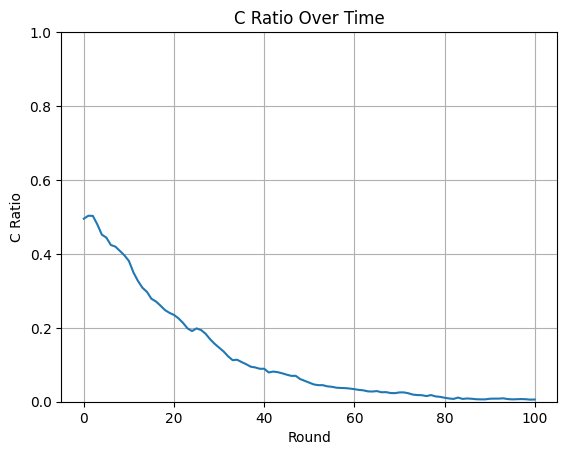

完全混合集団ゲーム


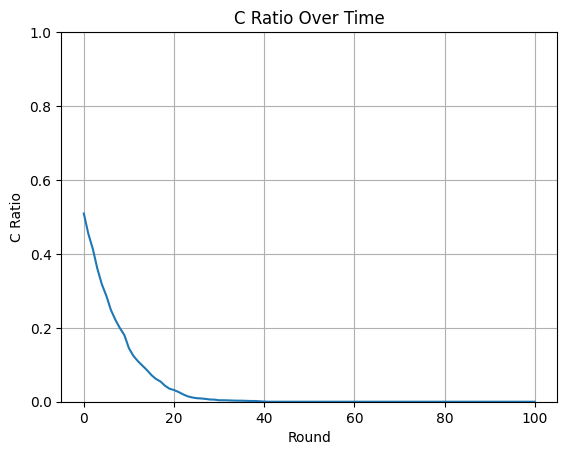

In [163]:
strgSet = ["C", "D"]
payMatrix = {
    "C": {"C": 5, "D": 0},
    "D": {"C": 6, "D": 1}
}

# 格子上ゲームを実行する
C_ratios_grid = simulate_game(
    strgSet=strgSet,
    payMatrix=payMatrix,
    exp_fn=Game.expFn_grid,
    L=50,
    rounds=100
)

print("格子上ゲーム")
plot_C_ratios(C_ratios_grid)

# 完全混合集団ゲームを実行する
C_ratios_mixed = simulate_game(
    strgSet=strgSet,
    payMatrix=payMatrix,
    exp_fn=Game.expFn_mixed,
    L=50,
    rounds=100
)


print("完全混合集団ゲーム")
plot_C_ratios(C_ratios_mixed)